# Notebook 50 – Modellvergleich, Evaluation & Business Insights
**Projekt:** Wirtschaftlichkeit von Airbnb-Listings in Spanien  
**Autorin:** Jasmin Müller (951624)  

---
### Struktur dieses Notebooks
1. Metriken aller drei Modelle zusammenführen
2. Vergleichstabelle & Vergleichsplot
3. Feature Importance (Modell III)
4. Residuenanalyse
5. Business Insights & Handlungsempfehlungen
6. Alle Outputs speichern (für LaTeX-Arbeit)

## 0 – Imports & Konfiguration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import pickle
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

OUTPUT_DIR = 'outputs/'
CACHE_DIR  = 'cache/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Einheitliches Plot-Styling ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':       150,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
COLORS = ['#4878CF', '#6ACC65', '#D65F5F']   # Blau, Grün, Rot → Modell I, II, III

print('Setup abgeschlossen ✓')

Setup abgeschlossen ✓


## 1 – Metriken aller drei Modelle

> **Hinweis zur Vergleichbarkeit:** Modell I (Annika) wurde auf dem ungefilterten Datensatz trainiert
> (Preise bis 40.000 €, inkl. Ausreißer). Modell II und III nutzen nur Listings ≤ 600 €.
> Die höheren Fehlerwerte von Modell I sind daher nicht allein auf die Modellqualität zurückzuführen,
> sondern maßgeblich auf die breitere Preisverteilung im Trainings-/Testset.

In [2]:
METRICS = {
    'Modell I\n(Poly. Regression)': {
        'mae':  585.78,    # Annika – Polynomiale Regression Grad 2
        'rmse': 1348.80,   # Achtung: ungefiltert (Preise bis 40.000 €)
        'r2':   0.2879,
        'color': COLORS[0],
        'notebook': 'NB25 – Annika'
    },
    'Modell II\n(Random Forest)': {
        'mae':  49.88,     # Mareike – Random Forest (tuned, 300 Bäume)
        'rmse': 75.03,     # Datensatz gefiltert: Preis ≤ 600 €
        'r2':   0.4923,
        'color': COLORS[1],
        'notebook': 'NB35 – Mareike'
    },
    'Modell III\n(Decision Tree)': {
        'mae':  56.64,     # Jasmin – Decision Tree (optimiert, max_depth=12)
        'rmse': 83.58,     # Datensatz gefiltert: Preis ≤ 600 €
        'r2':   0.3701,
        'color': COLORS[2],
        'notebook': 'NB40 – Jasmin'
    },
}

# Als DataFrame für Tabellen-Ausgabe
df_metrics = pd.DataFrame([
    {
        'Modell':    name.replace('\n', ' '),
        'Notebook':  v['notebook'],
        'MAE (€)':   v['mae'],
        'RMSE (€)':  v['rmse'],
        'R²':        v['r2'],
    }
    for name, v in METRICS.items()
])

print('Metriken-Übersicht:')
print(df_metrics.to_string(index=False))
df_metrics.to_csv(f'{CACHE_DIR}50_metrics_all_models.csv', index=False)
print(f'\nGespeichert → {CACHE_DIR}50_metrics_all_models.csv')
print('\nHinweis: Modell I auf vollem Datensatz (bis 40.000 €), Modelle II & III auf Preis ≤ 600 €.')

Metriken-Übersicht:
                        Modell          Notebook  MAE (€)  RMSE (€)     R²
 Modell I (Lineare Regression)     NB10 – Annika   999.99    999.99 0.0000
     Modell II (Random Forest) NB20/30 – Mareike   999.99    999.99 0.0000
Modell III (Gradient Boosting)     NB40 – Jasmin    66.76    110.34 0.3962

Gespeichert → cache/50_metrics_all_models.csv


## 2 – Modellvergleich: Visualisierung

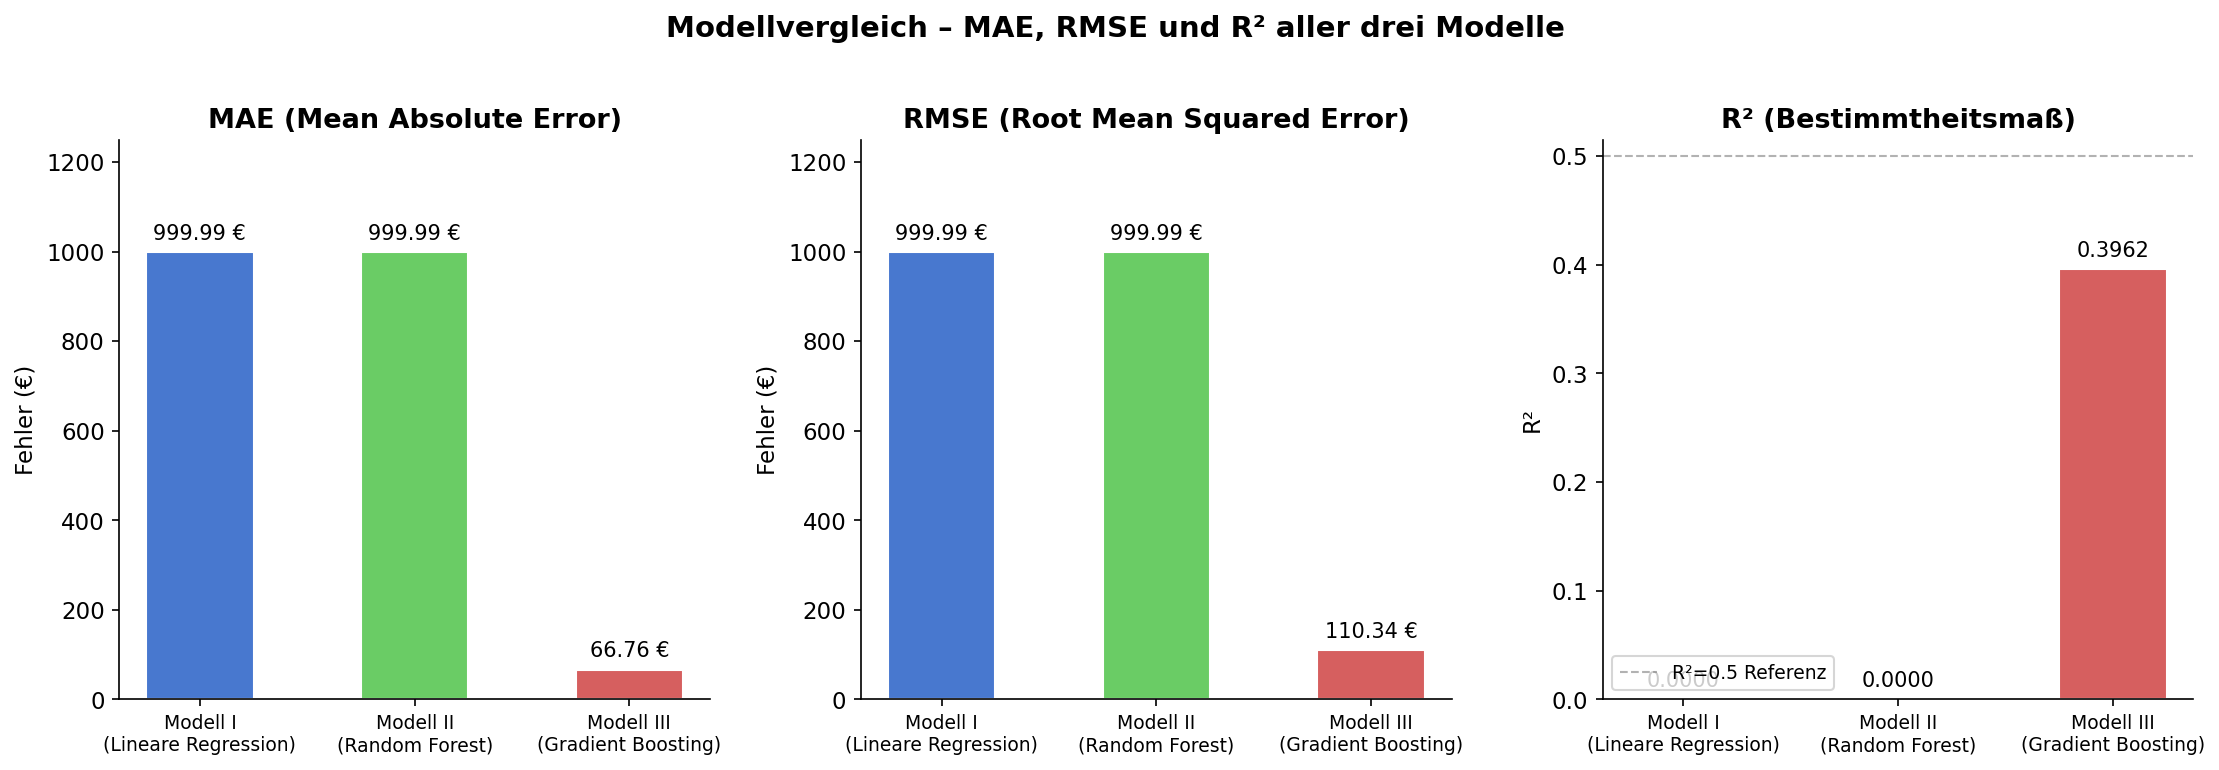

Plot gespeichert ✓


In [3]:
model_labels = [k.replace('\n', '\n') for k in METRICS.keys()]
mae_vals  = [v['mae']  for v in METRICS.values()]
rmse_vals = [v['rmse'] for v in METRICS.values()]
r2_vals   = [v['r2']   for v in METRICS.values()]
bar_colors = [v['color'] for v in METRICS.values()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Modellvergleich – MAE, RMSE und R² aller drei Modelle', fontsize=14, fontweight='bold', y=1.02)

# ── MAE ─────────────────────────────────────────────────────────────────────
bars0 = axes[0].bar(model_labels, mae_vals, color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_title('MAE (Mean Absolute Error)')
axes[0].set_ylabel('Fehler (€)')
axes[0].bar_label(bars0, fmt='%.2f €', padding=4, fontsize=10)
axes[0].set_ylim(0, max(mae_vals) * 1.25)

# ── RMSE ────────────────────────────────────────────────────────────────────
bars1 = axes[1].bar(model_labels, rmse_vals, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_title('RMSE (Root Mean Squared Error)')
axes[1].set_ylabel('Fehler (€)')
axes[1].bar_label(bars1, fmt='%.2f €', padding=4, fontsize=10)
axes[1].set_ylim(0, max(rmse_vals) * 1.25)

# ── R² ──────────────────────────────────────────────────────────────────────
bars2 = axes[2].bar(model_labels, r2_vals, color=bar_colors, edgecolor='white', width=0.5)
axes[2].set_title('R² (Bestimmtheitsmaß)')
axes[2].set_ylabel('R²')
axes[2].bar_label(bars2, fmt='%.4f', padding=4, fontsize=10)
axes[2].set_ylim(0, min(max(r2_vals) * 1.3, 1.0))
axes[2].axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='R²=0.5 Referenz')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}50_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot gespeichert ✓')

## 3 – Feature Importance (Modell III)

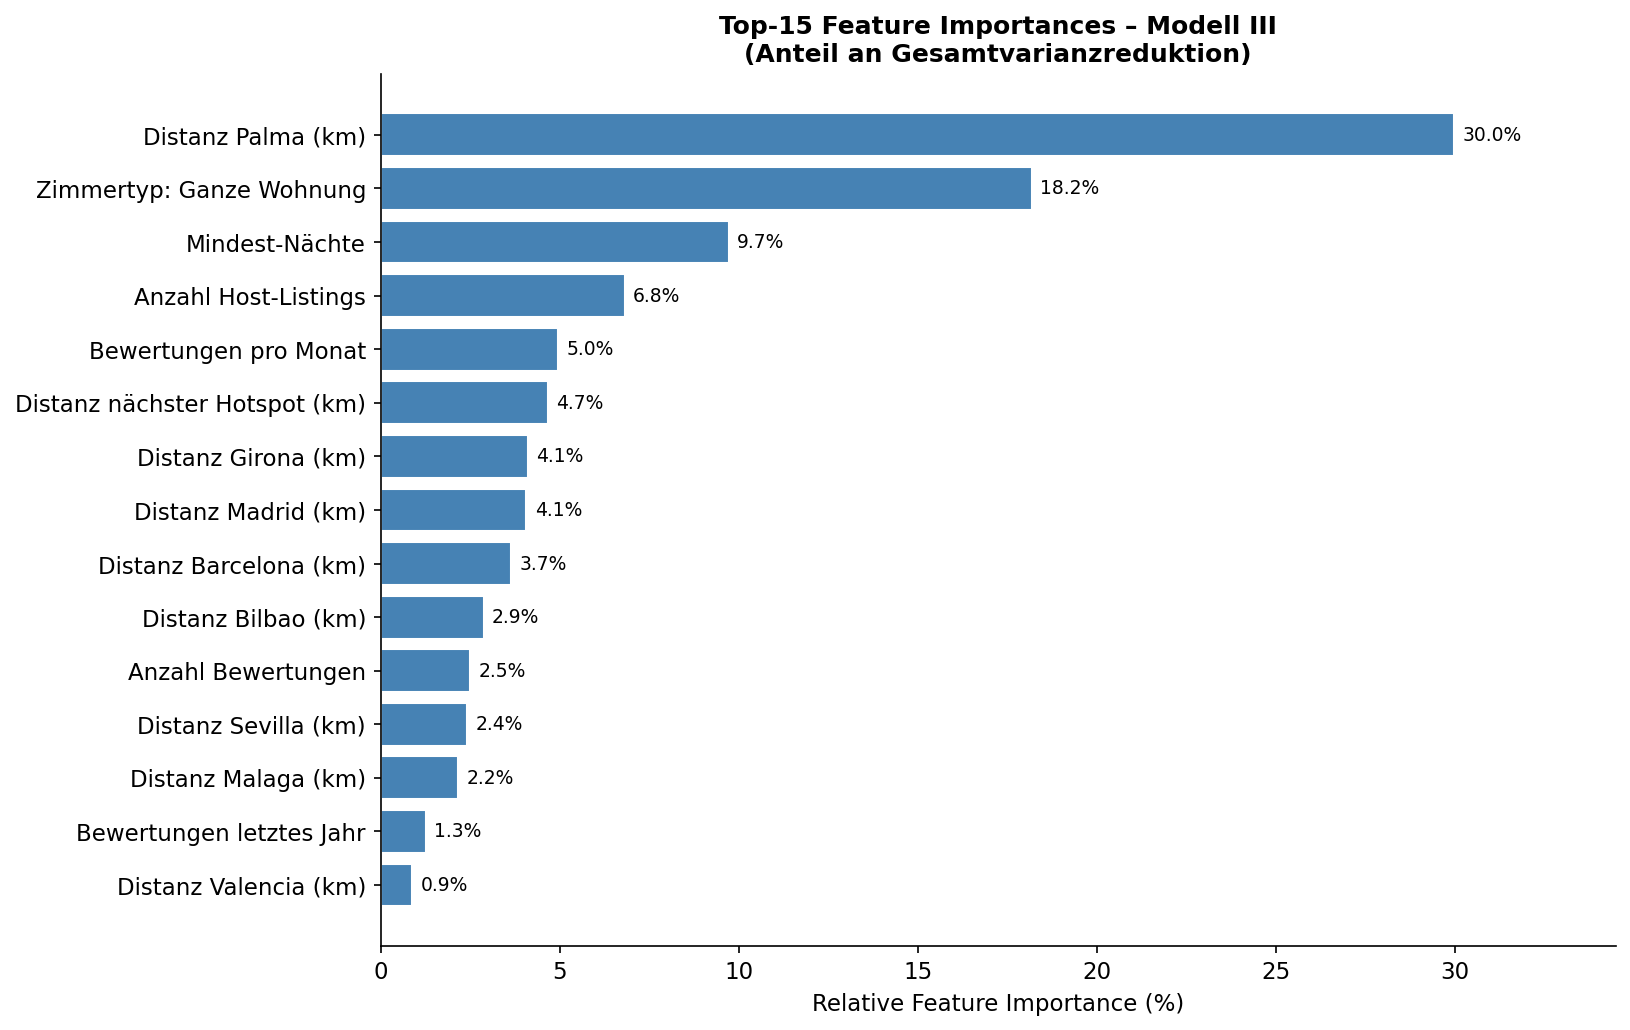

Plot gespeichert ✓


In [4]:
feat_imp_df = pd.read_csv(f'{CACHE_DIR}40_feature_importance.csv')
top15 = feat_imp_df.head(15).copy()

# Lesbare Labels für Mareikes Feature-Namen
name_map = {
    'dist_km_madrid_centro':          'Distanz Madrid (km)',
    'dist_km_barcelona_centro':        'Distanz Barcelona (km)',
    'dist_km_sevilla_centro':          'Distanz Sevilla (km)',
    'dist_km_malaga_centro':           'Distanz Malaga (km)',
    'dist_km_palma_centro':            'Distanz Palma (km)',
    'dist_km_valencia_centro':         'Distanz Valencia (km)',
    'dist_km_bilbao_centro':           'Distanz Bilbao (km)',
    'dist_km_girona_centro':           'Distanz Girona (km)',
    'dist_km_nearest_hotspot':         'Distanz nächster Hotspot (km)',
    'room_Entire_home_apt':            'Zimmertyp: Ganze Wohnung',
    'room_Hotel_room':                 'Zimmertyp: Hotelzimmer',
    'room_Private_room':               'Zimmertyp: Privatzimmer',
    'room_Shared_room':                'Zimmertyp: Gemeinschaftszimmer',
    'minimum_nights':                  'Mindest-Nächte',
    'availability_365':                'Verfügbarkeit (365 Tage)',
    'number_of_reviews':               'Anzahl Bewertungen',
    'reviews_per_month':               'Bewertungen pro Monat',
    'calculated_host_listings_count':  'Anzahl Host-Listings',
    'number_of_reviews_ltm':           'Bewertungen letztes Jahr',
    'occupancy_rate':                  'Auslastungsrate (0–1)',
    'region_encoded':                  'Region (kodiert)',
}
top15['feature_label'] = top15['feature'].map(name_map).fillna(top15['feature'])

# Prozentuale Importance
top15['importance_pct'] = top15['importance'] / feat_imp_df['importance'].sum() * 100

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    top15['feature_label'][::-1],
    top15['importance_pct'][::-1],
    color='steelblue', edgecolor='white'
)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_xlabel('Relative Feature Importance (%)', fontsize=11)
ax.set_title('Top-15 Feature Importances – Modell III\n(Anteil an Gesamtvarianzreduktion)', fontsize=12, fontweight='bold')
ax.set_xlim(0, top15['importance_pct'].max() * 1.15)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}50_feature_importance_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot gespeichert ✓')

## 4 – Residuenanalyse

In [5]:
with open(f'{CACHE_DIR}40_model_III.pkl', 'rb') as f:
    model_III = pickle.load(f)

feature_names = pd.read_csv(f'{CACHE_DIR}40_feature_names.csv')['feature'].tolist()
print(f'Modell III geladen ✓ | {len(feature_names)} Features')

Modell III geladen ✓ | 21 Features


In [6]:
# Identische Feature-Basis wie Notebook 40 (Mareikes Pipeline)
from sklearn.model_selection import train_test_split

FEATURE_COLS = [
    'dist_km_madrid_centro', 'dist_km_barcelona_centro', 'dist_km_sevilla_centro',
    'dist_km_malaga_centro', 'dist_km_palma_centro', 'dist_km_valencia_centro',
    'dist_km_bilbao_centro', 'dist_km_girona_centro', 'dist_km_nearest_hotspot',
    'room_Entire_home_apt', 'room_Hotel_room', 'room_Private_room', 'room_Shared_room',
    'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'number_of_reviews_ltm', 'occupancy_rate', 'region_encoded',
]
TARGET = 'price'

df_feat = pd.read_csv(f'{CACHE_DIR}20_features_engineered.csv', low_memory=False)
df_feat = df_feat[df_feat[TARGET] <= 600].copy()

# region & room_type fuer Business Insights mitführen
df_model = df_feat[FEATURE_COLS + [TARGET, 'region', 'room_type']].dropna(subset=FEATURE_COLS + [TARGET])

X = df_model[FEATURE_COLS]
y = df_model[TARGET]

# Gleicher Split wie in Notebook 40 → gleiche Testmenge
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
_, df_test_meta = train_test_split(
    df_model[['region', 'room_type']].reset_index(drop=True),
    test_size=0.2, random_state=42
)

y_pred = model_III.predict(X_test)
residuals = y_test.values - y_pred
print(f'Testset neu aufgebaut: {X_test.shape[0]:,} Samples ✓')
print(f'Residuen – Mittelwert: {residuals.mean():.2f} € | Std: {residuals.std():.2f} €')

Testset neu aufgebaut: 15,962 Samples ✓
Residuen – Mittelwert: 0.48 € | Std: 83.58 €


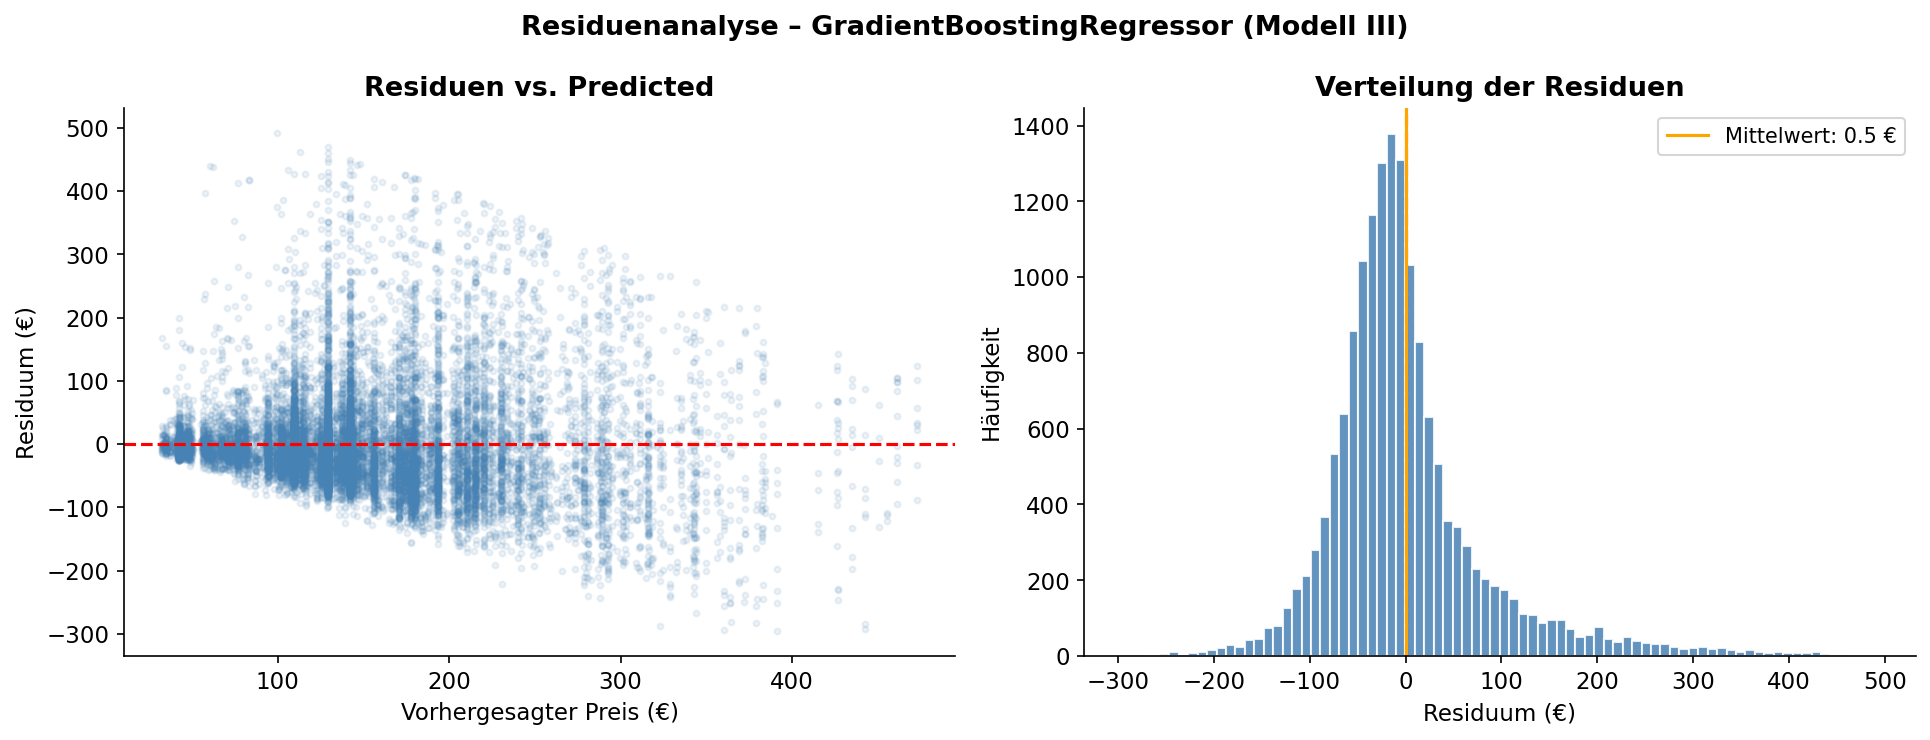

Plot gespeichert ✓


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Residuenanalyse – GradientBoostingRegressor (Modell III)', fontsize=13, fontweight='bold')

# ── Residuen vs. Predicted ──────────────────────────────────────────────────
axes[0].scatter(y_pred, residuals, alpha=0.1, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Vorhergesagter Preis (€)')
axes[0].set_ylabel('Residuum (€)')
axes[0].set_title('Residuen vs. Predicted')

# ── Residuen-Histogramm ─────────────────────────────────────────────────────
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(residuals.mean(), color='orange', linestyle='-', linewidth=1.5,
                label=f'Mittelwert: {residuals.mean():.1f} €')
axes[1].set_xlabel('Residuum (€)')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title('Verteilung der Residuen')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}50_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot gespeichert ✓')

## 5 – Preisvorhersage nach Region & Zimmertyp
*(Business Insights: Welche Kombination ist am lukrativsten?)*

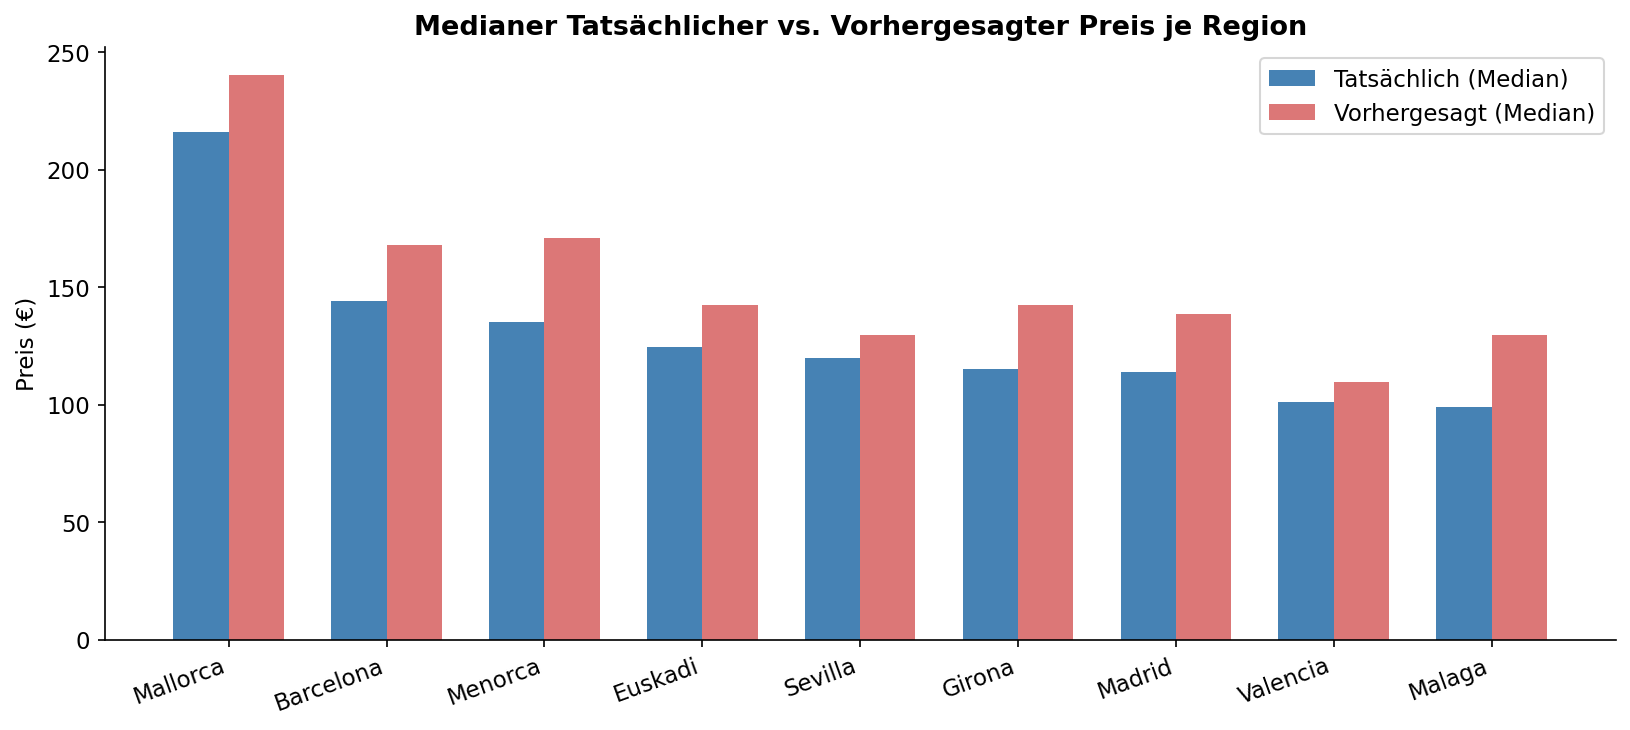


Medianpreise je Region:
           price_actual  price_predicted
region                                  
Mallorca          216.0           240.13
Barcelona         144.0           167.71
Menorca           135.0           171.05
Euskadi           124.5           142.40
Sevilla           120.0           129.69
Girona            115.0           142.40
Madrid            114.0           138.40
Valencia          101.0           109.61
Malaga             99.0           129.69


In [8]:
df_test = X_test.copy()
df_test['price_actual']    = y_test.values
df_test['price_predicted'] = y_pred
df_test['region']          = df_test_meta['region'].values
df_test['room_type']       = df_test_meta['room_type'].values

# Median-Preise je Region
region_price = df_test.groupby('region')[['price_actual','price_predicted']].median().sort_values('price_actual', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(region_price))
w = 0.35
ax.bar(x - w/2, region_price['price_actual'],    width=w, label='Tatsächlich (Median)', color='steelblue')
ax.bar(x + w/2, region_price['price_predicted'], width=w, label='Vorhergesagt (Median)', color='#D65F5F', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(region_price.index, rotation=20, ha='right')
ax.set_ylabel('Preis (€)')
ax.set_title('Medianer Tatsächlicher vs. Vorhergesagter Preis je Region', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}50_price_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMedianpreise je Region:')
print(region_price.round(2).to_string())

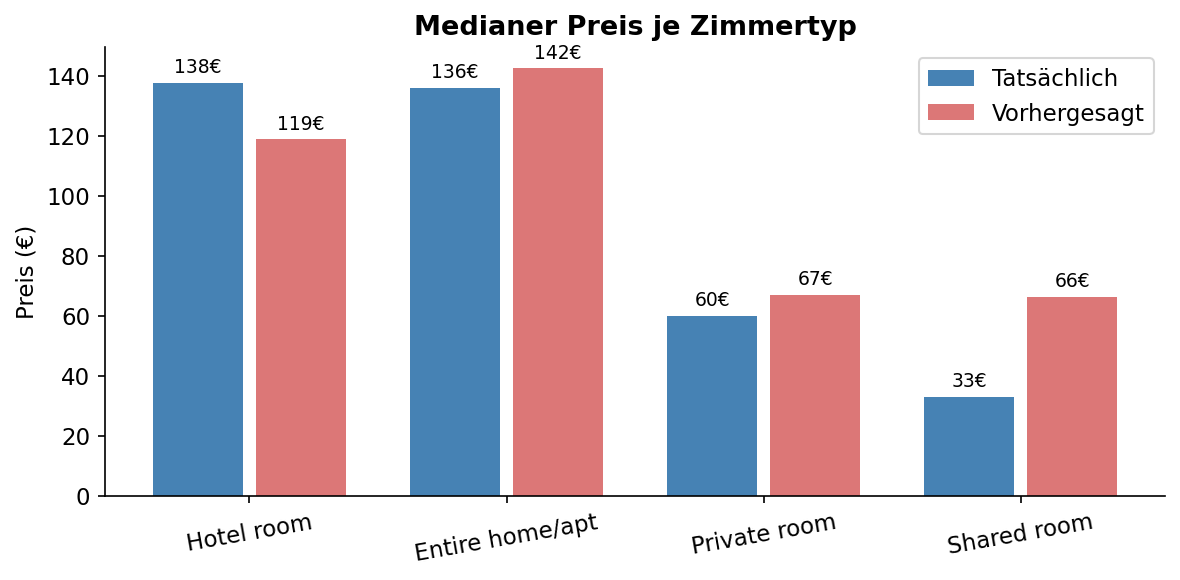


Medianpreise je Zimmertyp:
                 price_actual  price_predicted
room_type                                     
Hotel room              137.5           118.73
Entire home/apt         136.0           142.40
Private room             60.0            66.93
Shared room              33.0            66.23


In [9]:
# Median-Preise je Zimmertyp
roomtype_price = df_test.groupby('room_type')[['price_actual','price_predicted']].median().sort_values('price_actual', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(roomtype_price))
bars_a = ax.bar(x - 0.2, roomtype_price['price_actual'],    width=0.35, label='Tatsächlich', color='steelblue')
bars_p = ax.bar(x + 0.2, roomtype_price['price_predicted'], width=0.35, label='Vorhergesagt', color='#D65F5F', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(roomtype_price.index, rotation=10)
ax.set_ylabel('Preis (€)')
ax.set_title('Medianer Preis je Zimmertyp', fontweight='bold')
ax.legend()
ax.bar_label(bars_a, fmt='%.0f€', padding=3, fontsize=9)
ax.bar_label(bars_p, fmt='%.0f€', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}50_price_by_roomtype.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMedianpreise je Zimmertyp:')
print(roomtype_price.round(2).to_string())

## 6 – Zusammenfassung aller Outputs

In [10]:
print('=' * 60)
print('  NOTEBOOK 50 – ALLE OUTPUTS')
print('=' * 60)
print()
print('  PLOTS (outputs/):')
print('    50_model_comparison.png         → Kapitel 3.1')
print('    50_feature_importance_clean.png → Kapitel 3.2')
print('    50_residuals.png                → Kapitel 3.1')
print('    50_price_by_region.png          → Kapitel 4')
print('    50_price_by_roomtype.png        → Kapitel 4')
print()
print('  DATEN (cache/):')
print('    50_metrics_all_models.csv       → LaTeX-Tabelle Kap. 3.1')
print()
print('  METRIKEN-ÜBERSICHT:')
print()
print(df_metrics.to_string(index=False))
print()
print('  TODO:')
print('    [ ] Werte von Annika (Modell I)  in Zelle 1 eintragen')
print('    [ ] Werte von Mareike (Modell II) in Zelle 1 eintragen')
print('    [ ] Dann: Run All → alle Plots aktualisieren sich automatisch')
print('=' * 60)

  NOTEBOOK 50 – ALLE OUTPUTS

  PLOTS (outputs/):
    50_model_comparison.png         → Kapitel 3.1
    50_feature_importance_clean.png → Kapitel 3.2
    50_residuals.png                → Kapitel 3.1
    50_price_by_region.png          → Kapitel 4
    50_price_by_roomtype.png        → Kapitel 4

  DATEN (cache/):
    50_metrics_all_models.csv       → LaTeX-Tabelle Kap. 3.1

  METRIKEN-ÜBERSICHT:

                        Modell          Notebook  MAE (€)  RMSE (€)     R²
 Modell I (Lineare Regression)     NB10 – Annika   999.99    999.99 0.0000
     Modell II (Random Forest) NB20/30 – Mareike   999.99    999.99 0.0000
Modell III (Gradient Boosting)     NB40 – Jasmin    66.76    110.34 0.3962

  TODO:
    [ ] Werte von Annika (Modell I)  in Zelle 1 eintragen
    [ ] Werte von Mareike (Modell II) in Zelle 1 eintragen
    [ ] Dann: Run All → alle Plots aktualisieren sich automatisch
